# Lab 8: Implementation and Performance Evaluation of Categorical Naive Bayes Classifier

### Objective
The objective of this experiment is to implement a Categorical Naive Bayes classifier using the Play Tennis dataset. The categorical features are encoded into numerical values, and the model is trained and evaluated using standard classification metrics. Finally, the performance of Naive Bayes is compared with Decision Tree, Logistic Regression, and Support Vector Machine (SVM) classifiers.

## Step 1: Import Required Libraries

In this step, the necessary Python libraries are imported for data manipulation, preprocessing, machine learning model implementation, and performance evaluation.

In [18]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Step 2: Load the Dataset

The Play Tennis dataset is loaded using the Pandas library. If a serial number column is present, it is removed since it does not contribute to model training.

In [6]:
df = pd.read_csv("Lab 8 - Sheet1.csv")

# Remove serial number column if present
if "No" in df.columns:
    df = df.drop("No", axis=1)

print("Dataset:")
print(df)


Dataset:
     Outlook Temperature Humidity    Wind Play Tennis
0      Sunny         Hot     High    Weak          No
1      Sunny         Hot     High  Strong          No
2   Overcast         Hot     High    Weak         Yes
3       Rain        Mild     High    Weak         Yes
4       Rain        Cool   Normal    Weak         Yes
5       Rain        Cool   Normal  Strong          No
6   Overcast        Cool   Normal  Strong         Yes
7      Sunny        Mild     High    Weak          No
8      Sunny        Cool   Normal    Weak         Yes
9       Rain        Mild   Normal    Weak         Yes
10     Sunny        Mild   Normal  Strong         Yes
11  Overcast        Mild     High  Strong         Yes
12  Overcast         Hot   Normal    Weak         Yes
13      Rain        Mild     High  Strong          No
14     Sunny        Cool     High    Weak          No
15     Sunny        Cool     High  Strong          No
16     Sunny         Hot   Normal    Weak         Yes
17     Sunny       

## Step 3: Encode Categorical Features

Machine learning algorithms require numerical input. Therefore, all categorical feature values and the target variable are converted into numerical form using Label Encoding.

In [7]:
encoders = {}

for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    encoders[column] = le

print("\nEncoded Dataset:")
print(df)


Encoded Dataset:
    Outlook  Temperature  Humidity  Wind  Play Tennis
0         2            1         0     1            0
1         2            1         0     0            0
2         0            1         0     1            1
3         1            2         0     1            1
4         1            0         1     1            1
5         1            0         1     0            0
6         0            0         1     0            1
7         2            2         0     1            0
8         2            0         1     1            1
9         1            2         1     1            1
10        2            2         1     0            1
11        0            2         0     0            1
12        0            1         1     1            1
13        1            2         0     0            0
14        2            0         0     1            0
15        2            0         0     0            0
16        2            1         1     1            1
17        

## Step 4: Separate Features and Target Variable

The input features (Outlook, Temperature, Humidity, and Wind) are stored in the feature matrix **X**, while the target variable **Play Tennis** is stored in **y**.

In [8]:
X = df.drop("Play Tennis", axis=1)
y = df["Play Tennis"]

## Step 5: Split the Dataset

The dataset is divided into training and testing subsets using an 80:20 ratio. The training data is used to build the model, while the testing data is used to evaluate its performance.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


## Step 6: Train the Categorical Naive Bayes Model

A Categorical Naive Bayes classifier is created and trained using the encoded training dataset. This model is suitable for datasets containing categorical features.

In [10]:
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)

# Predictions
y_pred = nb_model.predict(X_test)

## Step 7: Evaluate the Model

The trained model predicts the labels of the test dataset. The following evaluation metrics are computed:

- Accuracy
- Confusion Matrix
- Classification Report
  - Precision
  - Recall
  - F1-Score

These metrics help determine the effectiveness of the classifier.

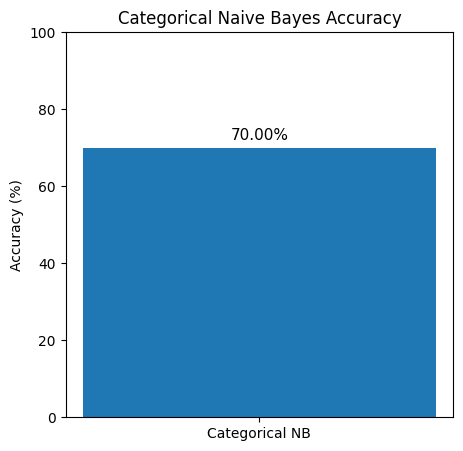

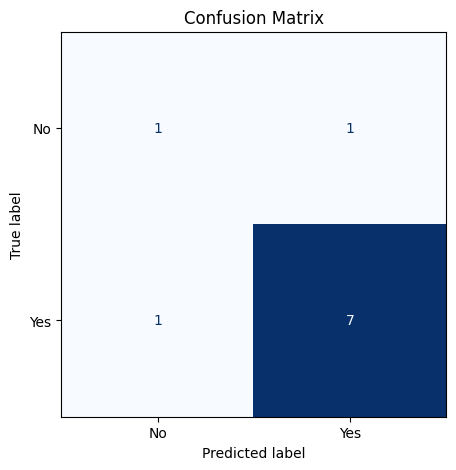

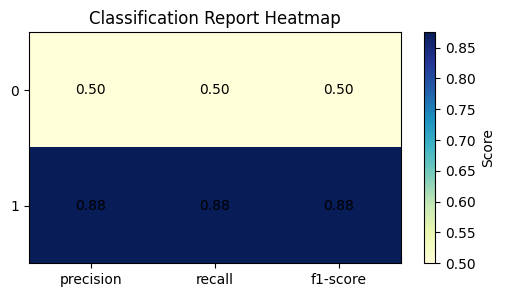


========== Categorical Naive Bayes ==========

Model Accuracy : 70.00%

Confusion Matrix
[[1 1]
 [1 7]]

Classification Report
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.88      0.88      0.88         8

    accuracy                           0.80        10
   macro avg       0.69      0.69      0.69        10
weighted avg       0.80      0.80      0.80        10



In [19]:
plt.figure(figsize=(5,5))
plt.bar(["Categorical NB"], [accuracy * 100], width=0.4)

plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("Categorical Naive Bayes Accuracy")

for i, v in enumerate([accuracy * 100]):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontsize=11)

plt.show()

# ============================================================
# Confusion Matrix Heatmap
# ============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoders["Play Tennis"].classes_
)

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix")
plt.show()

# ============================================================
# Classification Report Heatmap
# ============================================================

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Keep only class metrics (exclude accuracy and averages)
heatmap_data = report_df.iloc[:-3, :-1]

plt.figure(figsize=(6,3))

plt.imshow(heatmap_data, cmap="YlGnBu", aspect="auto")

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

# Display values inside cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.text(
            j,
            i,
            f"{heatmap_data.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar(label="Score")
plt.title("Classification Report Heatmap")
plt.show()

# ============================================================
# Print Evaluation Metrics
# ============================================================

print("\n========== Categorical Naive Bayes ==========")

print(f"\nModel Accuracy : {accuracy * 100:.2f}%")

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

## Step 8: Predict a New Sample

The trained Naive Bayes model is used to predict whether a person will play tennis under the following weather conditions:

- Outlook: Sunny
- Temperature: Cool
- Humidity: High
- Wind: Strong

The predicted class along with the probability of each possible class is displayed.

In [12]:
sample = pd.DataFrame({
    "Outlook": ["Sunny"],
    "Temperature": ["Cool"],
    "Humidity": ["High"],
    "Wind": ["Strong"]
})

# Encode sample
encoded_sample = sample.copy()

for col in sample.columns:
    encoded_sample[col] = encoders[col].transform(sample[col])

# Prediction
prediction = nb_model.predict(encoded_sample)
probabilities = nb_model.predict_proba(encoded_sample)

predicted_label = encoders["Play Tennis"].inverse_transform(prediction)

print("\n========== Single Sample Prediction ==========")
print("Weather Conditions")
print(sample)

print("\nPredicted Class :", predicted_label[0])

classes = encoders["Play Tennis"].inverse_transform(nb_model.classes_)

print("\nClass Probabilities")

for cls, prob in zip(classes, probabilities[0]):
    print(f"{cls} : {prob:.4f}")



========== Single Sample Prediction ==========
Weather Conditions
  Outlook Temperature Humidity    Wind
0   Sunny        Cool     High  Strong

Predicted Class : No

Class Probabilities
No : 0.9256
Yes : 0.0744


## Step 9: Compare Multiple Classification Models

To compare performance, three additional classifiers are trained using the same training data:

- Decision Tree Classifier
- Logistic Regression
- Support Vector Machine (SVM)

The models are compared based on:

- Test Accuracy
- Prediction for the given weather sample
- Predicted Class Probabilities

In [13]:
dt_model = DecisionTreeClassifier(random_state=42)

lr_model = LogisticRegression(max_iter=1000)

svm_model = SVC(probability=True, random_state=42)

models = {
    "Categorical Naive Bayes": nb_model,
    "Decision Tree": dt_model,
    "Logistic Regression": lr_model,
    "SVM": svm_model
}

results = []

print("\n========== Model Comparison ==========\n")

for name, model in models.items():

    # Skip already trained Naive Bayes
    if name != "Categorical Naive Bayes":
        model.fit(X_train, y_train)

    # Test prediction
    test_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, test_pred)

    # Sample prediction
    sample_pred = model.predict(encoded_sample)

    sample_label = encoders["Play Tennis"].inverse_transform(sample_pred)[0]

    probabilities = model.predict_proba(encoded_sample)[0]

    no_prob = probabilities[0]
    yes_prob = probabilities[1]

    results.append([
        name,
        round(accuracy * 100, 2),
        sample_label,
        round(no_prob, 4),
        round(yes_prob, 4)
    ])

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy (%)",
        "Prediction",
        "P(No)",
        "P(Yes)"
    ]
)

print(comparison)


========== Model Comparison ==========

                     Model  Accuracy (%) Prediction   P(No)  P(Yes)
0  Categorical Naive Bayes          80.0         No  0.9256  0.0744
1            Decision Tree          80.0         No  1.0000  0.0000
2      Logistic Regression          40.0         No  0.9439  0.0561
3                      SVM          70.0         No  0.9751  0.0249


## Result

The Categorical Naive Bayes classifier was successfully implemented and evaluated using the Play Tennis dataset. The model's performance was measured using accuracy, confusion matrix, and classification report. The trained model also predicted the class for a new weather instance and was compared with Decision Tree, Logistic Regression, and SVM classifiers.

## Analysis Report

The four classifiers use different learning strategies, resulting in different prediction confidence and probability estimates. Categorical Naive Bayes assumes that all features are conditionally independent, whereas Decision Trees learn rule-based splits from the training data. Logistic Regression estimates probabilities using a linear decision boundary, while SVM maximizes the margin between classes and estimates probabilities through calibration. Consequently, although multiple models may predict the same class label, their probability scores and confidence levels vary because of their different underlying assumptions.